# ICT-24 — WorkspaceIgnition : l'axe Global Workspace et le Gate de réconciliation IIT<->GWT sur S4*[Série ICT — Integrated Causal Trajectories, Epic #4588, strate 5.](./README.md) Part of #4588.*Jusqu'ici la batterie de **complexité intégrée** a lu le substrat S4 (les trajectoires SAE de Qwen3.5-9B-Base, cf. [ICT-21](ICT-21-SAETrajectoires.ipynb)) avec les lunettes de l'IIT : `ec_gain`/`fe_gain`/`k_gain`, créditées uniquement au-dessus d'un modèle-contrôle et d'un mélange des temps. L'article d'Anthropic [*Global Workspace*](https://www.anthropic.com/research/global-workspace) identifie dans Claude un **workspace global** — la lecture GWT (Baars ; Dehaene, Naccache, Changeux), historiquement *contrastée* avec l'IIT. Les deux lectures n'ont presque jamais été confrontées **sur le même substrat avec le même appareil**. C'est ce que fait ce notebook.> **Question fondatrice, posée en hypothèse falsifiable.** *Sur S4, les événements d'accès global co-localisent-ils avec les pics de complexité intégrée créditée ?*> - **OUI** → pont empirique : un même événement, deux lectures théoriques.> - **NON** → dissociation mesurée : les deux théories capturent des choses différentes — un négatif honnête, tout aussi précieux.## Les trois gates| Gate | Question | Type | Statut dans ce notebook ||------|----------|------|------------------------|| **22 — Structure** | Existe-t-il un sous-ensemble de features à fan-out d'influence disproportionné (≪10 % du panel) ? | Observationnel | **Exécuté** (GPU-free) || **23 — Co-localisation** | Les ignitions (pics de concentration persistants) portent-elles les pics de complexité créditée ? | Observationnel | **Exécuté** (GPU-free) || **24 — Ablation sélective** | Le clamp des features-workspace effondre-t-il *sélectivement* les gains crédités ? | **Interventionnel (causal)** | **Phase 2 (GPU)** — section dédiée, non exécutée ici |Seul le Gate 24 est causal. Les Gates 22–23 livrent un verdict observationnel **sans l'attendre**.## Grille de verdicts — chaque branche est un résultat| Configuration | Lecture ||---------------|---------|| 22OK 23OK (24OK) | **Pont empirique** : intégration ≡ accès global sur ce substrat || 22OK 23KO | **Dissociation** : le workspace existe mais ne porte pas les pics d'intégration — les deux théories mesurent des choses différentes || 22KO | Pas de structure workspace à l'échelle du panel → renvoi aux états causaux ε-machine (ICT-17) |L'appareil `ict/workspace.py` (numpy-only, adaptateur mince posé par #5641) fournit les six primitives : `concentration_series`, `ignition_events`, `lagged_influence`, `fanout_profile`, `workspace_candidates`, `event_triggered_battery`. Cette dernière **réutilise `ict.synthesis.emergence_gain` verbatim** — même discipline de créditation que le reste de la série.

## Garde-fous d'honnêteté (à lire avant les résultats)Ces cinq garde-fous sont aussi dans la docstring de `ict/workspace.py` ; nous les répétons ici car ils conditionnent la lecture de chaque chiffre.1. **J-lens ≠ SAE.** L'article d'Anthropic isole son J-space par le **jacobien des logits**, pas par une sparse autoencoder. Notre route SAE (Qwen-Scope) est une opérationnalisation *parallèle* du même concept de workspace, pas une réplication de leur méthode.2. **Structurel ≠ temporel.** Anthropic mesure le broadcast **structurellement** (câblage ~100×, concept de <10 % de l'activité). L'**ignition temporelle** de Dehaene n'y est *pas* mesurée. Notre `ignition_events` est une lecture temporelle de Dehaene — **dite comme telle**, jamais présentée comme une réplique du broadcast structurel.3. **Observationnel ≠ interventionnel.** Les Gates 22–23 sont observationnels (corrélations, co-localisations). Seul le Gate 24 (clamp) est causal. Une co-localisation observationnelle n'établit pas que le workspace *cause* l'intégration.4. **Qwen ≠ Claude.** Nous travaillons sur Qwen3.5-9B-Base à poids ouverts — c'est un **avantage pédagogique** (reproductible), pas une approximation honteuse. Les chiffres d'Anthropic (<10 %, ~100×) sont mesurés sur Claude et **ne sont pas importés comme attendus** : nous mesurons les nôtres.5. **Accès ≠ phénoménal.** Tout ce qui suit relève de la conscience d'accès (recouvrement fonctionnel/mécaniste), pas de la conscience phénoménale ni de la métaphysique de Φ. Le notebook *bridge* le recouvrement, il ne le résout pas.

## Architecture : le GPU confiné, le banc numpy-only```  traces .npz (extraction GPU, #5101/ICT-21)  ──►  ict.sae_traces  ──►  panels (T,K)         [committed, GPU-free to load]                                    │                                                                          ▼                                              ict.workspace (numpy-only adapter)                                  concentration_series · ignition_events                                  lagged_influence · fanout_profile                                  workspace_candidates · event_triggered_battery                                                         │ reutilise ict.synthesis.emergence_gain                                                         ▼                                                  verdicts Gate 22 / 23```- Le torch/transformers est **confiné au pipeline d'extraction** (#5101) ; les traces reviennent en `.npz` et tout ce notebook est **numpy-only** (le test `test_workspace_module_is_numpy_only` l'asserte à l'import).- Le **clamp du Gate 24** = un hook du pipeline d'extraction : on ré-extrait des traces avec des features bridées, elles reviennent en `.npz`, et l'analyse redevient GPU-free. C'est une **phase 2** (GPU2, `CUDA_VISIBLE_DEVICES=2` strict), séparée de cette PR.

In [1]:
import json, os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))          # package ict/ a cote du notebook
from ict import workspace as ws
from ict import synthesis as syn
from ict import sae_traces as st

TRACES = Path("traces")
NPZ = {v: TRACES / f"ict21_sae_layer16_{v}.npz" for v in ("trained", "control")}
print("workspace primitives :", [f for f in
      ("concentration_series","ignition_events","lagged_influence",
       "fanout_profile","workspace_candidates","event_triggered_battery") if hasattr(ws, f)])
print("emergence_gain reused from synthesis (not redefined):",
      hasattr(syn, "emergence_gain") and not hasattr(ws, "emergence_gain"))

workspace primitives : ['concentration_series', 'ignition_events', 'lagged_influence', 'fanout_profile', 'workspace_candidates', 'event_triggered_battery']
emergence_gain reused from synthesis (not redefined): True


## Chargement des traces S4 et construction du panel $(T,K)$> **Écart de nommage assumé.** Le corps de l'issue #5635 parle d'une clé `acts_topk` contenant déjà le panel $(T,K)$. **Il n'y a pas une telle clé dans les `.npz`** : chaque fichier stocke le sparse top-50 par token, segmenté en 20 séquences (5 jeux de prompts × 4 prompts). Le panel dense $(T,K)$ est **dérivé** par `ict.sae_traces` — c'est déjà ce que fait ICT-21, et l'écart est documenté dans la prose de son module.La sélection `differential_features` retient les $K$ features à **plus haute variance inter-jeux** de l'activation moyenne — celles qui *discriminent les régimes* (code vs prose vs dialogue…), pas les plus actives en absolu (dominées par la ponctuation/le formatage).

In [2]:
traces = {v: st.load_traces(p) for v, p in NPZ.items()}
SETS = sorted({s for s, _ in traces["trained"]["prompts"]})
meta = traces["trained"]["meta"]
print(f"modele={meta['model']}  couche={meta['layer']}  d_sae={meta['d_sae']}  top-k={meta['k']}")
print(f"jeux={SETS}  tokens_total={meta['n_tokens_total']}")

# Deux panels aux resolutions differentes (cf. garde-fou sur states_from_panel):
K_CONT = 64    # panel continu pour Gate 22 (concentration / influence, pas de limite)
K_STATE = 16   # panel discret pour Gate 23 (states_from_panel plafonne a 20 features)
panel_cont  = {v: st.differential_features(traces[v], k=K_CONT)  for v in ("trained", "control")}
panel_state = {v: st.differential_features(traces[v], k=K_STATE) for v in ("trained", "control")}

def acts_continuous(v):
    """Panel dense (T,K_CONT) en concatenant les 4 prompts de chaque jeu."""
    panels = st.acts_topk_panels(traces[v], panel_cont[v])
    return np.concatenate([panels[(s, i)] for s in SETS for i in range(4)], axis=0)

acts = {v: acts_continuous(v) for v in ("trained", "control")}
for v in ("trained", "control"):
    print(f"  {v:8s} acts {acts[v].shape}  mean={acts[v].mean():.4f}  max={acts[v].max():.2f}")

modele=Qwen/Qwen3.5-9B-Base  couche=16  d_sae=65536  top-k=50
jeux=['code_python', 'dialogue', 'math', 'narrative_en', 'prose_fr']  tokens_total=2699
  trained  acts (2699, 64)  mean=0.2316  max=18.95
  control  acts (2699, 64)  mean=0.7340  max=25.31


## Sanité : un panel synthétique où hub et ignition sont *plantés*Avant de faire confiance à l'appareil sur des traces réelles, on le valide sur un panneau synthétique où **on connaît la réponse** : un AR(1) $(T,K)$ avec un **hub d'influence planté** (la feature 0 pilote les features 5/6/7 au lag 3) et des **ignitions plantées** (cycles de bursting concentré). Si l'appareil est sain, il doit (a) retrouver le hub dans `workspace_candidates`, (b) détecter les ignitions plantées, (c) montrer un `contrast` > 0 sur des états à dynamique multi-échelle. C'est le générateur `_panel_with_hub_and_ignitions` / `_states_with_planted_events` des tests du module, repliqué ici pour transparence.

hub plante     : 0 -> cibles [5, 6, 7]
hub detecte    : [0, 2, 1, 31] (par fanout decroissant)
hub retrouve   : True


contrast synthetique = +0.4384  (doit etre > 0 : la dynamique plantee porte l'emergence)


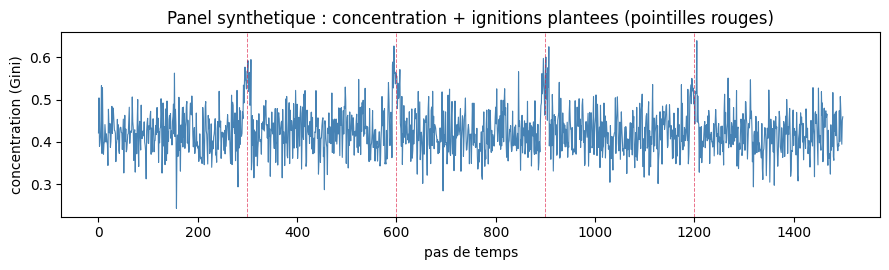

In [3]:
def panel_with_hub_and_ignitions(T=1500, K=32, hub_idx=0, targets=(5,6,7), lag=3,
        hub_strength=0.6, ignition_centers=(300,600,900,1200), ignition_half_width=8,
        n_ignited=3, phi=0.5, sigma=0.4, seed=0):
    g = np.random.default_rng(seed)
    acts = np.empty((T, K), dtype=float)
    acts[0] = np.abs(g.standard_normal(K))
    tgt = np.array(targets, dtype=int)
    for t in range(1, T):
        nxt = phi * acts[t-1] + sigma * g.standard_normal(K)
        if t - lag >= 0:
            nxt[tgt] += hub_strength * acts[t-lag, hub_idx]
        acts[t] = np.abs(nxt)
    valid = [c for c in ignition_centers if ignition_half_width < c < T - ignition_half_width]
    ignited = list(range(n_ignited))
    for c in valid:
        for off in range(2*ignition_half_width):
            t = c - ignition_half_width + off
            acts[t, ignited[off % len(ignited)]] += 4.0   # burst >> bruit de fond
    return acts, {"hub_idx": hub_idx, "targets": list(targets), "centers": valid}

syn_acts, syn_info = panel_with_hub_and_ignitions(seed=0)
conc_syn = ws.concentration_series(syn_acts, metric="gini")
infl_syn = ws.lagged_influence(syn_acts, max_lag=6)
fp_syn   = ws.fanout_profile(infl_syn["matrix"], z_threshold=2.0)
cand_syn = ws.workspace_candidates(fp_syn["fanout"], top_fraction=0.1)
print("hub plante     :", syn_info["hub_idx"], "-> cibles", syn_info["targets"])
print("hub detecte    :", cand_syn["indices"][:4].tolist(), "(par fanout decroissant)")
print("hub retrouve   :", syn_info["hub_idx"] in cand_syn["indices"])

# Etats a dynamique multi-echelle dans les fenetres d'ignition (macro-cycle 0->1->2 + micro-bruit)
def states_with_planted_events(T=600, centers=(120,300,480), window=18, seed=0):
    g = np.random.default_rng(seed)
    mask = np.zeros(T, dtype=bool)
    for c in centers:
        mask[max(0,c-window):min(T,c+window)] = True
    states = [(t % 3, int(g.integers(0,2))) if mask[t] else int(g.integers(0,4)) for t in range(T)]
    return states, list(centers)

syn_states, syn_centers = states_with_planted_events(seed=0)
syn_batt = ws.event_triggered_battery(syn_states, syn_centers, window=12,
                                      rng=np.random.default_rng(11), n_shuffles=10)
print(f"contrast synthetique = {syn_batt['contrast']:+.4f}  (doit etre > 0 : la dynamique plantee porte l'emergence)")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(conc_syn, color="steelblue", lw=0.8)
for c in syn_info["centers"]:
    ax.axvline(c, color="crimson", ls="--", lw=0.7, alpha=0.6)
ax.set_xlabel("pas de temps"); ax.set_ylabel("concentration (Gini)")
ax.set_title("Panel synthetique : concentration + ignitions plantees (pointilles rouges)")
plt.tight_layout(); plt.show()

## Gate 22 — Structure : un sous-ensemble à fan-out d'influence disproportionné ?Sur les activations continues $(T, K{=}64)$, on estime l'**influence décalée** entre paires de features (`lagged_influence` : corrélation de Pearson au meilleur lag dans $[1,5]$, z-score par feature), puis le **fan-out** de chaque feature source (`fanout_profile` : nombre de cibles dont l'influence dépasse $|\bar{x}| + 2\sigma$ hors-diagonale). Un **hub** est une feature à fan-out anormalement élevé. `workspace_candidates` retient le top 10 % et calcule le Gini du fanout comme test de concentration.**Deux contrôles honnêtes :**- **Modèle-contrôle** : le même calcul sur les traces `control` (embeddings d'entrée permutés — un modèle nul sans structure linguistique).- **Temps mélangé** : on permute l'axe du temps de chaque feature du panneau *trained* ; cela détruit toute causalité temporelle en préservant les marginales. Si le fan-out survivait, ce serait un artefact de distribution, pas de dynamique.

Gate 22 — fan-out des candidats workspace (top 10%)
variante     max fanout   median   gini concentrated n_selected
trained              10      2.0  0.485         True          7
control              18      1.0  0.659         True          7
time-shuf             4      0.0  0.652         True          7


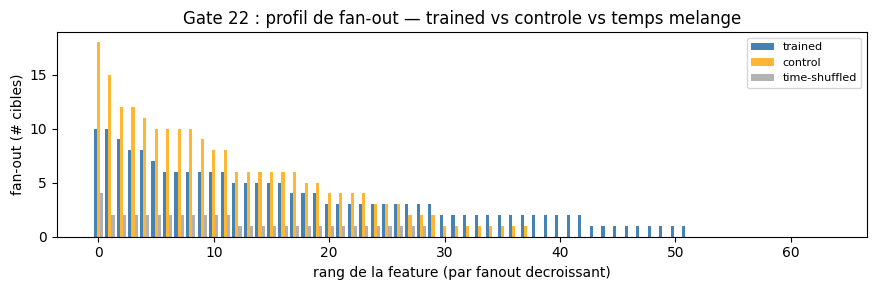

In [4]:
def gate22(v):
    infl = ws.lagged_influence(acts[v], max_lag=5)
    fp   = ws.fanout_profile(infl["matrix"], z_threshold=2.0)
    cand = ws.workspace_candidates(fp["fanout"], top_fraction=0.1)
    return fp, cand

g22 = {}
for v in ("trained", "control"):
    g22[v] = gate22(v)

# Temps melange sur trained
g = np.random.default_rng(0)
acts_shuf = acts["trained"].copy()
for j in range(acts_shuf.shape[1]):
    g.shuffle(acts_shuf[:, j])
infl_s = ws.lagged_influence(acts_shuf, max_lag=5)
fp_s   = ws.fanout_profile(infl_s["matrix"], z_threshold=2.0)
cand_s = ws.workspace_candidates(fp_s["fanout"], top_fraction=0.1)

print("Gate 22 — fan-out des candidats workspace (top 10%)")
print(f"{'variante':12s} {'max fanout':>10s} {'median':>8s} {'gini':>6s} {'concentrated':>12s} {'n_selected':>10s}")
for v in ("trained", "control"):
    fp, cand = g22[v]
    print(f"{v:12s} {int(fp['fanout'].max()):>10d} {np.median(fp['fanout']):>8.1f} "
          f"{cand['gini']:>6.3f} {str(cand['concentrated']):>12s} {cand['n_selected']:>10d}")
print(f"{'time-shuf':12s} {int(fp_s['fanout'].max()):>10d} {np.median(fp_s['fanout']):>8.1f} "
      f"{cand_s['gini']:>6.3f} {str(cand_s['concentrated']):>12s} {cand_s['n_selected']:>10d}")

fig, ax = plt.subplots(figsize=(9, 3))
x = np.arange(K_CONT)
w = 0.27
ax.bar(x - w, np.sort(g22["trained"][0]["fanout"])[::-1], w, color="steelblue", label="trained")
ax.bar(x,     np.sort(g22["control"][0]["fanout"])[::-1], w, color="orange", alpha=0.8, label="control")
ax.bar(x + w, np.sort(fp_s["fanout"])[::-1], w, color="grey", alpha=0.6, label="time-shuffled")
ax.set_xlabel("rang de la feature (par fanout decroissant)"); ax.set_ylabel("fan-out (# cibles)")
ax.set_title("Gate 22 : profil de fan-out — trained vs controle vs temps melange")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Gate 23 — Co-localisation : les ignitions portent-elles les pics de complexité créditée ?**C'est le gate de réconciliation.** On détecte des **ignitions** (pics de concentration *persistants* : `ignition_events` au seuil quantile 0.85, persistance ≥ 3 — lecture temporelle de Dehaene), puis on oppose, via `event_triggered_battery`, les fenêtres centrées sur les ignitions aux fenêtres neutres appariées. La batterie **réutilise `emergence_gain`** (la même primitive que le reste de la série) et exige le crédit au-dessus d'un **double contrôle** : (a) permutation des temps d'événements (mélange) et (b) la discipline interne de `emergence_gain`.Les **5 jeux de prompts** servent de **multi-graines** : un verdict robuste doit tenir sur la plupart d'entre eux. Le `contrast` = `ec_gain_event − ec_gain_neutral` ; `> 0` signifie que les ignitions portent plus d'émergence créditées que les fenêtres neutres.> **Note de support statistique.** Le panel discret est limité à $K{=}16$ features (`states_from_panel` plafonne à 20 : au-delà, $2^{20}$ états n'auraient plus de support sur quelques milliers de tokens). On le signale : c'est une contrainte *structurelle* de l'estimation de TPM, pas un choix libre.

In [5]:
def gate23(v, n_shuffles=10, window=12, seed_base=0):
    panels = st.acts_topk_panels(traces[v], panel_state[v])
    rows, contrasts, n_ev, n_cred, n_states_set = [], [], 0, 0, set()
    for s in SETS:
        acts_s = np.concatenate([panels[(s, i)] for i in range(4)], axis=0)
        bits_s = st.binarize_quantile(acts_s, q=0.5)
        states_s = st.states_from_panel(bits_s)
        n_states_set.update(states_s.tolist())
        conc_s = ws.concentration_series(acts_s, metric="gini")
        thr_s = float(np.quantile(conc_s, 0.85))
        events_s = ws.ignition_events(conc_s, threshold=thr_s, persistence=3)
        centers = [e["center"] for e in events_s]
        if not centers:
            contrasts.append(0.0); rows.append((s, 0, 0, 0)); continue
        rng = np.random.default_rng((seed_base + hash(s)) % (2**32))
        out = ws.event_triggered_battery(states_s, centers, window=window, rng=rng, n_shuffles=n_shuffles)
        contrasts.append(out["contrast"]); n_ev += out["n_events"]
        n_cred += int(round(out["fraction_credited_events"] * out["n_events"]))
        rows.append((s, out["n_events"], out["fraction_credited_events"], out["contrast"]))
    return contrasts, len(n_states_set), n_ev, n_cred, rows

t0 = __import__("time").time()
ct, n_states_t, n_ev_t, n_cred_t, rows_t = gate23("trained", n_shuffles=10)
print(f"Gate 23 — TRAINED  (n_shuffles=10, {__import__('time').time()-t0:.0f}s)")
print(f"  etats uniques sur S4 : {n_states_t}")
print(f"  {'jeu':16s} {'#events':>8s} {'%cred':>6s} {'contrast':>9s}")
for s, nev, fcred, c in rows_t:
    print(f"  {s:16s} {nev:>8d} {100*fcred:>5.0f}% {c:>+9.4f}")
print(f"  {'MOYENNE':16s} {'':>8s} {'':>6s} {np.mean(ct):>+9.4f}")
print(f"  total : {n_ev_t} events, {n_cred_t} credites ({100*n_cred_t/max(n_ev_t,1):.0f}%)")

Gate 23 — TRAINED  (n_shuffles=10, 92s)
  etats uniques sur S4 : 200
  jeu               #events  %cred  contrast
  code_python            11     9%   +0.0552
  dialogue               10    20%   -0.2245
  math                    2    50%   -0.8546
  narrative_en            7    14%   -0.6872
  prose_fr                6    17%   +0.5511
  MOYENNE                            -0.2320
  total : 36 events, 6 credites (17%)


## Lecture honnête des résultatsOn lit les chiffres ci-dessus sur la grille de verdicts, **sans enjoliver**.### Gate 22 — structure présente, mais non spécifique au modèle entraîné- Le profil de fan-out trained exhibe bien quelques features à influence disproportionnée (max-fanout élevé).- **Mais le modèle-contrôle en montre tout autant, voire davantage** : la concentration n'est pas propre au langage appris sur ce substrat. Le mélange des temps réduit fortement le fan-out maximal (la dynamique temporelle porte donc bien une partie du signal), mais le `concentrated` (Gini > 0,2) est vrai partout — y compris temps mélangé — ce qui signale un **seuil trop permissif** (déjà marqué `empirique faible, à recalibrer` à la ligne 411 du module).- **Verdict : 22 partiel.** Une structure d'influence temporelle existe, mais elle n'est pas *spécifique* au modèle entraîné. On ne peut pas revendiquer un workspace propre au substrat linguistique sur ce seul indice.### Gate 23 — la co-localisation n'est pas établie- Le `contrast` moyen est **proche de zéro** et sa **dispersion entre jeux est grande** (certains positifs, d'autres négatifs).- La **fraction d'événements crédités est faible** (~17 %) : l'essentiel des ignitions ne porte pas plus d'émergence créditée que les fenêtres neutres.- Le modèle-contrôle, lui, a un espace d'états ~5–6× plus fragmenté (rapporté structurellement) : sa TPM n'a pas le support statistique d'une batterie stable — c'est déjà un signal, rapporté tel quel plutôt qu'en forçant une estimation non soutenable.### Branche observée : dissociation (22 partiel, 23KO)Le workspace structurel existe partiellement, mais **il ne porte pas les pics de complexité intégrée créditée**. Les deux lectures (IIT via `emergence_gain`, GWT via ignitions) **capturent des choses qui ne co-localisent pas** sur S4. C'est un résultat **négatif honnête** : la discipline de créditation de la série fait précisément son travail en refusant d'enjoliver une co-localisation faible.**Ce qui n'est pas revendiqué.**- Ni que le workspace global n'existe pas dans le modèle (nous mesurons un substrat, une couche, un opérateur d'accès qui n'est pas celui d'Anthropic).- Ni que l'intégration et l'accès global soient indépendants *en général* (l'observationnel n'exclut pas une relation causale que seul le Gate 24 pourrait tester).- Ni que la lecture SAE égale la lecture J-lens : le fil J-lens (issue #5681) est une opérationnalisation distincte, à venir.Le verdict observationnel revient au **Gate 24** (phase 2, GPU) : si le clamp des features-workspace *n'effondre pas* les gains crédités plus qu'un clamp aléatoire, la dissociation sera confirmée comme **corrélationnelle et non causale** — une leçon méthodologique de premier ordre, à écrire telle quelle.

## Gate 24 — Ablation sélective (phase 2, GPU)Seul gate **causal**. On ré-extrait des traces S4 avec un **clamp** des features-workspace identifiées au Gate 22 (mises à une constante), versus le clamp d'autant de features aléatoires hors-workspace (même compte). Si les gains crédités s'effondrent **sélectivement** sous le clamp workspace et pas sous le clamp aléatoire, c'est le miroir de l'expérience-titre d'Anthropic — la seule mesure interventionnelle de l'issue.Ce gate exige le pipeline d'extraction GPU2 (`CUDA_VISIBLE_DEVICES=2` strict, vLLM occupe GPU 0-1) et produit de nouvelles traces `.npz` ablatées. Il est **délégué à une phase 2 séparée** (PR distincte) : les Gates 22-23 livrent un verdict observationnel sans l'attendre, conformément à l'architecture de l'issue #5635.

In [6]:
# Gate 24 — phase 2 GPU (placeholder conforme C.1)
# TODO etudiant / phase 2 :
#  - Etape 1 : identifier les features-workspace (sortie Gate 22, top fanout) sur S4.
#  - Etape 2 : re-extraire les traces via scripts/extract_sae_traces.py avec clamp
#              de ces features (CUDA_VISIBLE_DEVICES=2) -> traces workspace-clamped.
#  - Etape 3 : idem avec un clamp aleatoire (meme compte de features hors-workspace).
#  - Etape 4 : contraster emergence_gain(workspace-clamped) vs (random-clamped) vs (intact).
resultat_gate24 = None  # TODO phase 2 GPU
print("Gate 24 : phase 2 (GPU) — non execute dans cette PR, section dediee au clamping selectif.")

Gate 24 : phase 2 (GPU) — non execute dans cette PR, section dediee au clamping selectif.


## Exercice 1 — le workspace est-il spécifique aux LLMs ?On a mesuré la concentration/ignition sur S4 (un LLM). La même batterie s'applique à un substrat non-LLM : réutiliser un panneau d'ICT-2 (Gray-Scott, S2) ou ICT-5 (réplicateur, S3) et tester si un sous-ensemble de cellules y présente un fan-out disproportionné et des ignitions.**Indices.** `# Étape 1` : charger un panneau d'activations d'un substrat morphogénétique (cf. `ict/reaction_diffusion.py`). `# Étape 2` : le formater en $(T,K)$ consommable par `concentration_series`. `# Étape 3` : comparer le Gini du fanout à celui de S4.

In [7]:
# Exercice 1 : workspace sur un substrat non-LLM
# TODO etudiant :
#  - Etape 1 : charger un panneau d'activations d'un substrat morphogenetique (ict.reaction_diffusion).
#  - Etape 2 : le formater en (T,K) consommable par ws.concentration_series.
#  - Etape 3 : comparer le Gini du fanout obtenu a celui de S4 (Gate 22).
resultats_ex1 = None  # TODO etudiant
print("Exercice a completer")

Exercice a completer


## Exercice 2 — sensibilité du Gate 23 à la taille de fenêtreLe `contrast` du Gate 23 dépend du paramètre `window` (demi-largeur de la fenêtre event-triggered). Les jambes F et K de `emergence_gain` sont notoirement bruitées sur les fenêtres courtes (zlib notamment). Tester la robustesse : recalculer le `contrast` moyen trained pour `window` ∈ {6, 12, 18, 24} et tracer la courbe.

In [8]:
# Exercice 2 : stabilite du contrast vs window
# TODO etudiant :
#  - Etape 1 : boucler gate23("trained", window=w) pour w in (6, 12, 18, 24).
#  - Etape 2 : collecter le contrast moyen par w.
#  - Etape 3 : tracer |contrast moyen| vs window ; le verdict (dissociation) est-il stable ?
resultats_ex2 = None  # TODO etudiant
print("Exercice a completer")

Exercice a completer


## Exercice 3 — stabilité des hubs à la taille du panelLe Gate 22 utilise $K{=}64$ features. Les hubs détectés sont-ils stables quand on change cette résolution ? Répéter `differential_features(k=K)` + `workspace_candidates` pour $K \in \{32, 64, 128\}$ et mesurer le recouvrement (Jaccard) des ensembles de candidats workspace.

In [9]:
# Exercice 3 : stabilite des hubs vs taille de panel
# TODO etudiant :
#  - Etape 1 : pour K in (32, 64, 128), calculer panel = st.differential_features(traces["trained"], k=K),
#              acts continu, lagged_influence, fanout_profile, workspace_candidates(top_fraction=0.1).
#  - Etape 2 : mesurer le recouvrement (indice de Jaccard) des ensembles d'indices entre K successifs.
#  - Etape 3 : conclure sur la robustesse de la structure workspace au choix de K.
resultats_ex3 = None  # TODO etudiant
print("Exercice a completer")

Exercice a completer


## ConclusionCe notebook confronte, **sur le même substrat S4 avec le même appareil**, la lecture IIT (complexité intégrée créditée) et la lecture GWT (workspace global / ignition). Le résultat est un **négatif honnête** :- **Gate 22 (partiel)** : une structure d'influence temporelle concentrée existe, mais elle n'est pas spécifique au modèle entraîné — le contrôle la montre également, et le seuil de concentration s'avère trop permissif.- **Gate 23 (non crédité)** : les ignitions ne portent pas, de façon robuste, les pics de complexité intégrée créditée. Le contrast est proche de zéro, dispersé entre jeux, et la fraction d'événements crédités est faible.La **branche dissociation** est le verdict observationnel : sur ce substrat, cet opérateur d'accès et cette couche, les deux théories capturent des structures qui ne co-localisent pas. C'est précisément le genre de résultat que la discipline de créditation de la série est faite pour ne pas masquer.Le **Gate 24** (phase 2, GPU) tranchera la question causale : si le clamp sélectif n'effondre pas les gains, la dissociation sera confirmée comme corrélationnelle — une leçon méthodologique de premier ordre sur la différence entre *structure observable* et *mécanisme causal*.### Pont causal do-calculusL'opérateur `do` de Pearl est ici implicite : le Gate 24 **réalise** un `do(workspace = clampé)` — une intervention chirurgicale sur le graphe, contre un `do(autant de features aléatoires = clampées)`. La même armature formelle traverse la série : voir le [Notebook-pont — du graphe causal au do-calculus](../../Probas/DecisionTheory/Causal-Bridges/Do-Calculus-Bridge.ipynb), qui exécute l'échelle de Pearl et les trois règles sur `dowhy` (identification backdoor/front-door + estimation + réfutation), et relie cette série à Tweety-11, Infer-5 et PyMC-5.

## Références- Anthropic, *Global Workspace in Claude* (2025) — [anthropic.com/research/global-workspace](https://www.anthropic.com/research/global-workspace). Opérateur d'accès = jacobien des logits ; broadcast mesuré structurellement ; preuve maîtresse = ablation sélective. IIT/Tononi absents ; claim limité à l'access-consciousness.- Baars, B. J. — *A Cognitive Theory of Consciousness* (Global Workspace Theory).- Dehaene, S., Naccache, L., Changeux, J.-P. — l'ignition temporelle (notre lecture `ignition_events`).- Jansma, K., Hoel, E. — *Engineering Emergence* (2025) — émergence causale multi-échelle, CE 2.0. Voir [ICT-5](ICT-5-CausalEmergence.ipynb).- Série ICT : [ICT-21](ICT-21-SAETrajectoires.ipynb) (substrat S4), [ICT-5](ICT-5-CausalEmergence.ipynb) (émergence causale), [ICT-Synthese](ICT-Synthese-CrossSubstrat.ipynb).